# Autoencoder: „kenne ich nicht"

Das CNN in `cnn.ipynb` kennt zwei Klassen und presst alles in eine davon — ein Kreis kam dort als *square, 98,9 %* heraus. Hier lernt ein Netz stattdessen, **wie deine Bilder aussehen**, ganz ohne Labels.

Encoder quetscht das Bild auf 8 Zahlen, Decoder baut daraus wieder ein Bild. Was ins gelernte Schema passt, kommt sauber heraus. Was nicht, wird schlecht rekonstruiert — der **Rekonstruktionsfehler** ist dann groß, und das ist das Warnsignal.

**Ablauf:**
1. Bilder laden, Netz bauen
2. Training auf 80 Bildern (ohne Labels), mit Verschieben gegen Auswendiglernen
3. Schwelle aus den 20 zurückgehaltenen Bildern
4. Fremde Formen erzeugen und schauen, wie viele auffliegen
5. Demo mit Schwellen-Regler und Pfad-Tester

**Ergebnis vorweg:** das funktioniert nur halb. Wie gut, steht in Abschnitt 4 — und warum, ganz unten.

In [10]:
import os
# ponytail: Anaconda (MKL) und torch bringen beide libiomp5md.dll mit -> Abbruch beim Import.
# Muss VOR dem torch-Import stehen.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pathlib import Path
from io import BytesIO

torch.manual_seed(0)
DATA, GROESSE = Path("shapes_dataset"), 64

def lade(quelle):
    """Pfad, Bytes oder PIL-Bild -> 64x64 Graustufen, je Bild auf 0..1 gestreckt."""
    if isinstance(quelle, Image.Image):
        bild = quelle
    else:
        daten = quelle if isinstance(quelle, bytes) else Path(quelle).read_bytes()
        bild = Image.open(BytesIO(daten))
    a = np.asarray(bild.convert("L").resize((GROESSE, GROESSE)), dtype=np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-6)   # Helligkeit rausrechnen

pfade = np.array(sorted((DATA/"squares").glob("*.png")) +
                 sorted((DATA/"triangles").glob("*.png")))
X = torch.tensor(np.stack([lade(p) for p in pfade]))[:, None]   # (100, 1, 64, 64)

rng = np.random.default_rng(0)
mischung = rng.permutation(len(X))
train, prueffeld = mischung[:80], mischung[80:]   # Labels braucht hier niemand
print(f"{tuple(X.shape)}  |  {len(train)} Train, {len(prueffeld)} zurueckgehalten")

(100, 1, 64, 64)  |  80 Train, 20 zurueckgehalten


## 1. Das Netz

Ein Sanduhr-Netz. Die schmalste Stelle heißt **Engpass** (englisch *bottleneck*) und ist hier 8 Zahlen groß.

Diese 8 Zahlen sind der ganze Punkt: 4096 Pixel müssen durch sie hindurch. Das Netz kann sich nicht alles merken, es muss sich das Wesentliche aussuchen — Position, Größe, Form.

`ConvTranspose2d` ist die Umkehrung der Faltung: statt zu verkleinern, vergrößert es 8 → 16 → 32 → 64.

In [11]:
ENGPASS = 8

class Autoencoder(nn.Module):
    def __init__(self, engpass=ENGPASS):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  8, 3, stride=2, padding=1), nn.ReLU(),   # 64 -> 32
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),   # 32 -> 16
            nn.Conv2d(16, 16, 3, stride=2, padding=1), nn.ReLU(),  # 16 ->  8
            nn.Flatten(), nn.Linear(16*8*8, engpass),              # 1024 ->  8
        )
        # Bewusst KEINE Sigmoid am Ausgang: 93 % des Bildes ist schwarzer Hintergrund,
        # das Netz drueckt alles gegen 0 und landet im flachen Teil der Sigmoid.
        # Dort sind die Gradienten ~0 und das Training bleibt bei "alles schwarz" stehen.
        self.decoder = nn.Sequential(
            nn.Linear(engpass, 16*8*8), nn.ReLU(),
            nn.Unflatten(1, (16, 8, 8)),
            nn.ConvTranspose2d(16, 16, 4, stride=2, padding=1), nn.ReLU(),   #  8 -> 16
            nn.ConvTranspose2d(16, 8, 4, stride=2, padding=1),  nn.ReLU(),   # 16 -> 32
            nn.ConvTranspose2d(8,  1, 4, stride=2, padding=1),                # 32 -> 64
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

modell = Autoencoder()
print(f"Engpass: {ENGPASS} Zahlen fuer {GROESSE*GROESSE} Pixel")
print(f"Parameter: {sum(p.numel() for p in modell.parameters())}")

Engpass: 8 Zahlen fuer 4096 Pixel
Parameter: 27281


## 2. Training

Ziel ist nicht „welche Klasse", sondern „gib das Bild möglichst genau wieder aus". Eingabe und Sollwert sind dasselbe Bild — deshalb braucht es keine Labels.

**Warum verschoben wird:** 27.000 Parameter auf 80 Bilder heißt Auswendiglernen. Ohne das Verschieben lag der Fehler auf Trainingsbildern bei 0,004 und auf zurückgehaltenen bei 0,024 — Faktor 6, und damit hätte die Schwelle jedes zweite bekannte Bild abgelehnt. Ein zufälliger Versatz pro Schritt macht jedes Bild jedes Mal etwas anders, und die Lücke schließt sich.

Dauert rund zwei Minuten.

Epoche  300  Verlust 0.02095
Epoche  600  Verlust 0.00817
Epoche  900  Verlust 0.00648
Epoche 1200  Verlust 0.00564
Epoche 1500  Verlust 0.00533


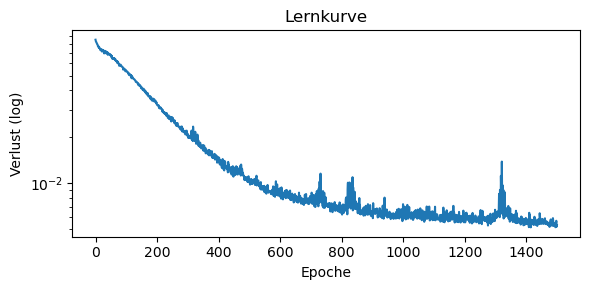

In [12]:
def verschiebe(x, m=6):
    """Zufaelliger Versatz um bis zu m Pixel, mit Schwarz aufgefuellt (kein Umlauf)."""
    dx, dy = np.random.randint(-m, m+1, 2)
    gepolstert = F.pad(x, (m, m, m, m))
    return gepolstert[:, :, m+dy:m+dy+GROESSE, m+dx:m+dx+GROESSE]

np.random.seed(0)
opt = torch.optim.Adam(modell.parameters(), lr=0.002)
verlust_fn = nn.MSELoss()

verlauf = []
for epoche in range(1500):
    modell.train()
    opt.zero_grad()
    eingabe = verschiebe(X[train])
    verlust = verlust_fn(modell(eingabe), eingabe)   # Eingabe == Sollwert
    verlust.backward(); opt.step()
    verlauf.append(verlust.item())
    if epoche % 300 == 299:
        print(f"Epoche {epoche+1:4d}  Verlust {verlust.item():.5f}")

plt.figure(figsize=(6, 3))
plt.plot(verlauf); plt.yscale("log")
plt.xlabel("Epoche"); plt.ylabel("Verlust (log)"); plt.title("Lernkurve")
plt.tight_layout(); plt.show()

## 3. Fehler messen und Schwelle setzen

Der Rekonstruktionsfehler ist die mittlere quadratische Abweichung zwischen Original und Nachbau — eine Zahl pro Bild.

Die Schwelle kommt aus den **zurückgehaltenen** Bildern, nicht aus den Trainingsbildern. Auf Trainingsbildern ist das Netz immer zu gut, eine Schwelle von dort wäre zu scharf und würde bekannte Bilder ablehnen.

In [13]:
def fehler(x):
    """x: (N,1,64,64) -> ein Fehlerwert je Bild."""
    modell.eval()
    with torch.no_grad():
        return ((modell(x) - x) ** 2).mean((1, 2, 3)).numpy()

fehler_train, fehler_bekannt = fehler(X[train]), fehler(X[prueffeld])
SCHWELLE = float(np.quantile(fehler_bekannt, 0.95))

print(f"Fehler Train        : {fehler_train.mean():.5f}  (Mittel)")
print(f"Fehler zurueckgehalten: {fehler_bekannt.mean():.5f}  (Mittel)   <- kaum hoeher, gut")
print(f"Schwelle            : {SCHWELLE:.5f}")

Fehler Train        : 0.00527  (Mittel)
Fehler zurueckgehalten: 0.00815  (Mittel)   <- kaum hoeher, gut
Schwelle            : 0.01534


## 4. Fremde Formen erzeugen

Ohne Gegenbeispiele lässt sich nicht behaupten, dass die Schwelle etwas taugt. Die neuen Formen bekommen bewusst **dieselbe Größe (44–130 px) und Helligkeit (80–254)** wie der echte Datensatz — sonst würde der Autoencoder sie an Größe oder Helligkeit erkennen statt an der Form, und das Ergebnis wäre geschönt.

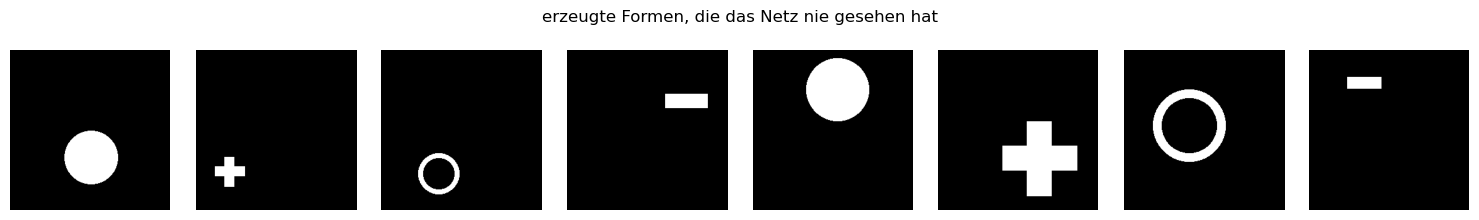

In [14]:
def mal_form(art, wuerfel):
    """Erzeugt ein 256x256-Bild im Stil des Datensatzes: helle Form auf schwarz."""
    bild = Image.new("L", (256, 256), 0)
    stift = ImageDraw.Draw(bild)
    s = int(wuerfel.integers(44, 131))                      # wie im echten Datensatz
    x = int(wuerfel.integers(0, 256 - s)); y = int(wuerfel.integers(0, 256 - s))
    hell = int(wuerfel.integers(80, 255))

    if art == "kreis":
        stift.ellipse([x, y, x+s, y+s], fill=hell)
    elif art == "kreuz":
        d = s // 3
        stift.rectangle([x+d, y, x+2*d, y+s], fill=hell)
        stift.rectangle([x, y+d, x+s, y+2*d], fill=hell)
    elif art == "ring":
        stift.ellipse([x, y, x+s, y+s], outline=hell, width=max(3, s//8))
    elif art == "balken":
        stift.rectangle([x, y + s//3, x+s, y + 2*s//3], fill=hell)
    else:
        raise ValueError(f"unbekannte Art: {art}")
    return bild

ARTEN = ["kreis", "kreuz", "ring", "balken"]
wuerfel = np.random.default_rng(1)
fremd_bilder = [mal_form(ARTEN[i % len(ARTEN)], wuerfel) for i in range(80)]
fremd_art    = np.array([ARTEN[i % len(ARTEN)] for i in range(80)])
fremd = torch.tensor(np.stack([lade(b) for b in fremd_bilder]))[:, None]
fehler_fremd = fehler(fremd)

fig, axs = plt.subplots(1, 8, figsize=(15, 2.2))
for ax, bild in zip(axs, fremd_bilder[:8]):
    ax.imshow(np.asarray(bild), cmap="gray"); ax.axis("off")
fig.suptitle("erzeugte Formen, die das Netz nie gesehen hat")
plt.tight_layout(); plt.show()

### Der Regler zeigt den Kompromiss

Links schiebst du die Schwelle, rechts siehst du sofort, was sie kostet:

- **weit links** — nichts kommt durch, jede fremde Form fliegt auf, aber auch deine eigenen Bilder werden abgelehnt
- **weit rechts** — alle bekannten Bilder kommen durch, aber fremde Formen rutschen mit

Die beiden Zahlen bewegen sich immer gegeneinander. Der Regler setzt auch `SCHWELLE` für die Demo weiter unten.

In [15]:
from ipywidgets import interact, FloatSlider

obergrenze = float(max(fehler_bekannt.max(), fehler_fremd.max()))

@interact(schwelle=FloatSlider(SCHWELLE, min=0, max=obergrenze, step=obergrenze/200,
                               readout_format=".4f", description="Schwelle",
                               layout={"width": "90%"}))
def regler(schwelle):
    global SCHWELLE
    SCHWELLE = float(schwelle)                    # gilt ab jetzt auch fuer pruefe()

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8),
                                 gridspec_kw={"width_ratios": [1.6, 1]})
    a1.hist(fehler_train,   bins=25, alpha=.65, label="Train (bekannt)")
    a1.hist(fehler_bekannt, bins=25, alpha=.65, label="zurueckgehalten (bekannt)")
    a1.hist(fehler_fremd,   bins=25, alpha=.65, label="fremde Formen")
    a1.axvline(schwelle, color="k", lw=2)
    a1.set(xlabel="Rekonstruktionsfehler", ylabel="Anzahl Bilder")
    a1.legend(fontsize=8)

    durchgelassen = (fehler_bekannt <= schwelle).mean()
    erwischt      = (fehler_fremd   >  schwelle).mean()
    a2.barh(["bekannte\ndurchgelassen", "fremde\nerwischt"], [durchgelassen, erwischt],
            color=["tab:green", "tab:red"])
    a2.set(xlim=(0, 1), title=f"Schwelle {schwelle:.5f}")
    for k, wert in enumerate([durchgelassen, erwischt]):
        a2.text(min(wert + .02, .75), k, f"{wert*100:.0f}%", va="center")
    plt.tight_layout(); plt.show()

    print("  je Form erwischt:  " + "   ".join(
        f"{art} {(fehler_fremd[fremd_art == art] > schwelle).mean()*100:.0f}%" for art in ARTEN))

interactive(children=(FloatSlider(value=0.015340720303356647, description='Schwelle', layout=Layout(width='90%…

## 5. Demo: Original, Nachbau, Differenz

Das Differenzbild zeigt, **wo** der Nachbau danebenliegt. Bei bekannten Formen ist es fast leer, bei fremden leuchten die Stellen auf, die nicht ins gelernte Schema passen.

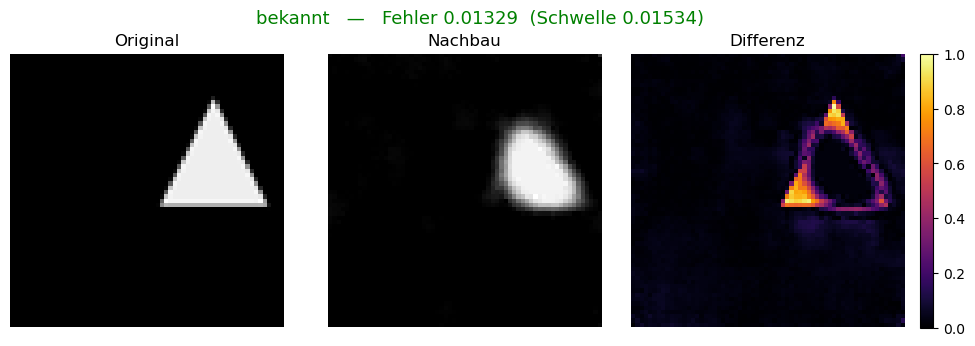

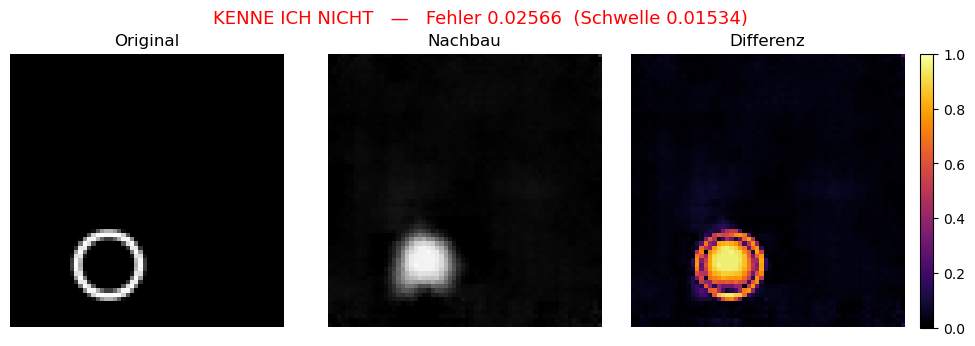

In [16]:
def pruefe(quelle, achsen=None):
    """quelle = Pfad, Bytes oder PIL-Bild. Gibt (bekannt?, Fehler) zurueck."""
    x = torch.tensor(lade(quelle))[None, None]
    modell.eval()
    with torch.no_grad():
        nachbau = modell(x)
    f = float(((nachbau - x) ** 2).mean())
    bekannt = f <= SCHWELLE

    a1, a2, a3 = achsen if achsen is not None else plt.subplots(1, 3, figsize=(10, 3.4))[1]
    a1.imshow(x[0, 0], cmap="gray", vmin=0, vmax=1);       a1.set_title("Original")
    a2.imshow(nachbau[0, 0], cmap="gray", vmin=0, vmax=1); a2.set_title("Nachbau")
    bild = a3.imshow((nachbau - x)[0, 0].abs(), cmap="inferno", vmin=0, vmax=1)
    a3.set_title("Differenz")
    plt.colorbar(bild, ax=a3, fraction=.046)
    for a in (a1, a2, a3):
        a.axis("off")

    urteil = "bekannt" if bekannt else "KENNE ICH NICHT"
    a1.figure.suptitle(f"{urteil}   —   Fehler {f:.5f}  (Schwelle {SCHWELLE:.5f})",
                       color="green" if bekannt else "red", fontsize=13)
    return bekannt, f

pruefe(pfade[int(prueffeld[0])]); plt.tight_layout(); plt.show()   # bekanntes Bild
pruefe(fremd_bilder[2]);          plt.tight_layout(); plt.show()   # Ring

## 6. Eigenes Bild prüfen

Pfad eintragen, Enter. Anführungszeichen von Windows „Als Pfad kopieren" werden abgeschnitten.

**Eigenes Fenster links:** Rechtsklick auf die Ausgabe dieser Zelle → *Create New View for Cell Output*, dann den Reiter an den linken Rand ziehen.

In [17]:
import ipywidgets as w
from IPython.display import display

# continuous_update=False ist wichtig: sonst feuert das Feld bei JEDEM Tastendruck
# und rechnet fuer jeden Zwischenstand des Pfades ein Bild durch. Sieht aus wie haengen.
pfad_feld = w.Text(value=str(pfade[int(prueffeld[0])]), placeholder=r"C:\Pfad\zu\bild.png",
                   description="Bild:", continuous_update=False,
                   layout=w.Layout(width="99%"), style={"description_width": "45px"})
knopf   = w.Button(description="Pruefen", button_style="primary", icon="search")
ausgabe = w.Output()

def ausfuehren(_=None):
    with ausgabe:
        ausgabe.clear_output(wait=True)
        try:
            pruefe(pfad_feld.value.strip().strip('"'))
            plt.tight_layout(); plt.show()
        except Exception as fehler_text:
            print(f"Geht nicht: {fehler_text}")

knopf.on_click(ausfuehren)
pfad_feld.observe(lambda _: ausfuehren(), names="value")   # feuert bei Enter / Verlassen des Feldes

display(w.VBox([pfad_feld, knopf, ausgabe]))
ausfuehren()

## Was dabei herauskommt, und warum

Bei der Standardschwelle 0,0153: **95 % der bekannten Bilder kommen durch, 57 % der fremden Formen fliegen auf.** Aufgeschlüsselt:

| Form | erwischt |
|---|---|
| Ring | 85 % |
| Kreuz | 65 % |
| Balken | 65 % |
| **Kreis** | **15 %** |

Das ist ehrlich mittelmäßig, und es liegt an der Aufgabe, nicht an einem Fehler im Aufbau.

**Der Ring geht am besten**, weil er ein Loch hat — eine Struktur, die in 8 Zahlen aus lauter gefüllten Quadraten und Dreiecken nicht vorkommt.

**Der Kreis ist der harte Fall.** Ein Autoencoder auf „heller Klecks vor schwarz" lernt genau das: heller Klecks vor schwarz. Ein Kreis ist auch einer. Das Netz baut ihn passabel nach, der Fehler bleibt klein, er rutscht durch.

Durchprobiert und verworfen:

| Versuch | Ergebnis |
|---|---|
| Sigmoid am Ausgang (erster Anlauf) | Training kollabiert auf „alles schwarz" |
| ohne Verschieben trainieren | lernt auswendig, lehnt bekannte Bilder ab |
| Engpass auf 4 statt 8 verengen | 98 % durchgelassen, aber nur 46 % erwischt |
| Engpass auf 2 | rekonstruiert gar nichts mehr, 0 % erwischt |
| Fehler nur auf der Form messen statt über das ganze Bild | schlechter als schlichtes MSE |
| 1200 erzeugte Formen statt 80 echte | Generalisierung perfekt, Erkennung schlechter |

Der Kompromiss ist strukturell: je besser der Autoencoder rekonstruiert, desto besser rekonstruiert er auch Unbekanntes. Am Regler oben siehst du das direkt — schieb ihn nach links und die 57 % steigen, aber die 95 % fallen.

**Was wirklich helfen würde**, wenn du das ernsthaft brauchst: dem CNN eine dritte Klasse „sonstiges" geben und mit Gegenbeispielen trainieren. Der Generator `mal_form` oben liefert die schon. Das ist die langweilige Lösung, aber sie funktioniert — der Autoencoder ist der elegantere Weg und hier der schwächere.

## Selbstcheck

In [18]:
assert verlauf[-1] < verlauf[0] / 10,      "Verlust kaum gefallen — Training kaputt"
assert fehler_bekannt.mean() < 2 * fehler_train.mean(), \
    f"auswendig gelernt: Train {fehler_train.mean():.5f} vs zurueckgehalten {fehler_bekannt.mean():.5f}"
assert fehler_fremd.mean() > 2 * fehler_bekannt.mean(), \
    "fremde Formen muessen deutlich schlechter rekonstruiert werden"

SCHWELLE = float(np.quantile(fehler_bekannt, 0.95))       # Reglerstand zuruecksetzen
assert (fehler_bekannt <= SCHWELLE).mean() >= 0.9,        "zu viele bekannte Bilder abgelehnt"

bekannt, f_bekannt = pruefe(pfade[int(train[0])]); plt.close("all")
assert bekannt, f"Trainingsbild als fremd eingestuft (Fehler {f_bekannt:.5f})"
assert pruefe(pfade[int(train[0])].read_bytes())[1] == f_bekannt, \
    "Pfad und Bytes liefern Unterschiedliches"
plt.close("all")

print("Selbstcheck ok")

Selbstcheck ok
